# CNN Track: Training Diagnostics

Visual diagnostics for the CNN-only, CNN+LSTM v1, and CNN+LSTM v2 models

What to look for (from NB02/NB03/NB10):
- **Overfitting**: train loss keeps dropping but val loss rises or flattens
- **Underfitting**: both curves are flat and high
- **Generalization**: test tracks val closely (good) or diverges upward (bad)
- **Capacity**: bigger model doesn't always mean better val loss

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

REPO_DIR = Path('/content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM')
output_root = REPO_DIR / 'outputs'
print(f'Loading from: {output_root}')

# Load saved loss histories
# Order matters: controls subplot left-to-right order
histories = {}
for name in ['cnn_only', 'cnn_lstm', 'cnn_lstm_v2']:
    history_path = output_root / name / 'loss_history.json'
    if history_path.exists():
        with open(history_path) as f:
            histories[name] = json.load(f)
        print(f'  Loaded {name}')
    else:
        print(f'  Skipped {name} ({history_path})')

assert len(histories) > 0, f'No histories found in {output_root}'

LABELS = {
    'cnn_only': ('CNN-only', 'tab:orange'),
    'cnn_lstm': ('CNN+LSTM v1 (h=128, L=1)', 'tab:blue'),
    'cnn_lstm_v2': ('CNN+LSTM v2 (h=256, L=2)', 'tab:green'),
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading from: /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs
  Loaded cnn_only
  Loaded cnn_lstm
  Loaded cnn_lstm_v2


## 1. Train vs Val per model (overfitting check)

NB02: "if you find that you have overfit, retrain from scratch and select epochs based on where your previous best results were found"

Look for the gap between train (solid) and val (dashed)

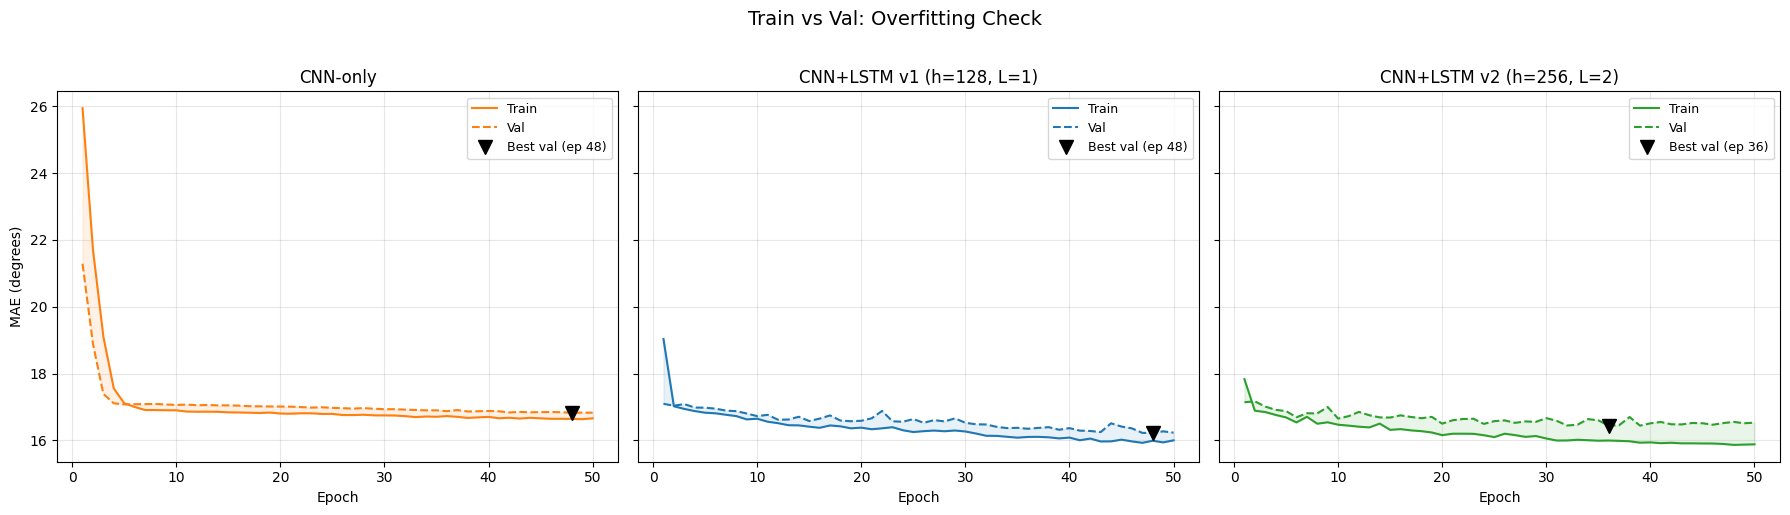

In [13]:
n = len(histories)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True, squeeze=False)
axes = axes[0]

for ax, name in zip(axes, histories):
    label, color = LABELS[name]
    epochs = range(1, len(histories[name]['train_loss']) + 1)
    train_deg = np.rad2deg(histories[name]['train_loss'])
    val_deg = np.rad2deg(histories[name]['val_loss'])

    ax.plot(epochs, train_deg, color=color, label='Train')
    ax.plot(epochs, val_deg, color=color, linestyle='--', label='Val')

    # Mark best val epoch
    best_idx = int(np.argmin(histories[name]['val_loss']))
    ax.plot(best_idx + 1, val_deg[best_idx], 'v', color='black', markersize=10,
            label=f'Best val (ep {best_idx + 1})')

    # Shade the train-val gap
    ax.fill_between(epochs, train_deg, val_deg, alpha=0.1, color=color)

    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('MAE (degrees)')
fig.suptitle('Train vs Val: Overfitting Check', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 2. All models compared (train and val)

Side-by-side: which model learns fastest and which plateaus

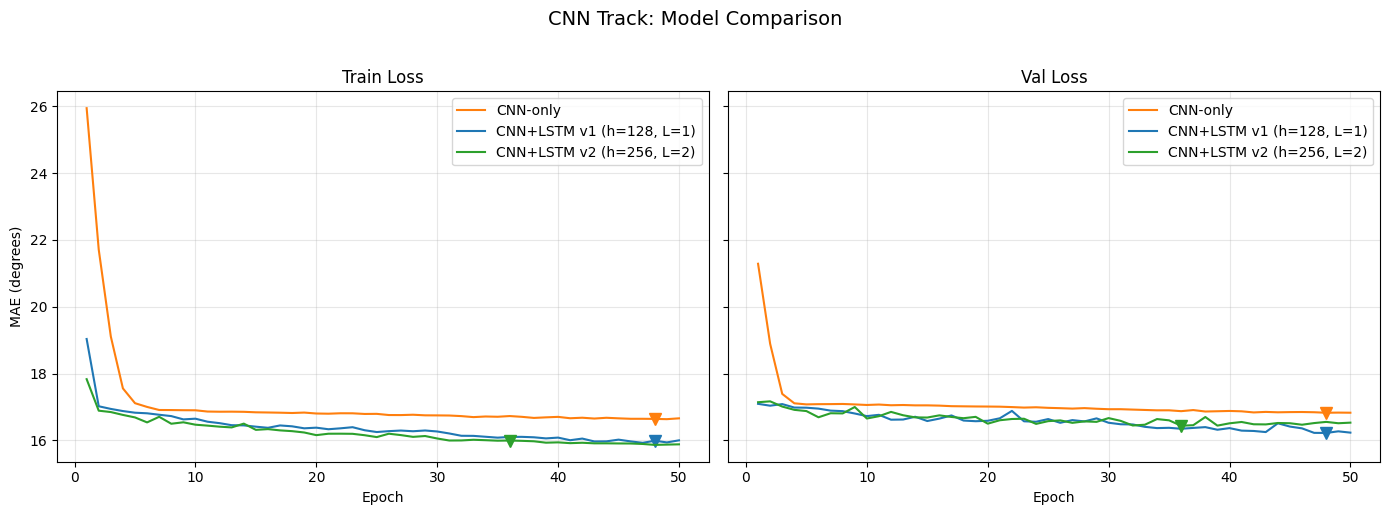

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, split, title in [
    (axes[0], 'train_loss', 'Train Loss'),
    (axes[1], 'val_loss', 'Val Loss'),
]:
    for name in histories:
        label, color = LABELS[name]
        epochs = range(1, len(histories[name][split]) + 1)
        vals_deg = np.rad2deg(histories[name][split])
        ax.plot(epochs, vals_deg, color=color, label=label)

        # Mark best val epoch on both panels
        best_idx = int(np.argmin(histories[name]['val_loss']))
        ax.plot(best_idx + 1, vals_deg[best_idx], 'v', color=color, markersize=8)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('MAE (degrees)')
fig.suptitle('CNN Track: Model Comparison', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 3. Val vs Test per model (generalization check)

If test tracks val closely, the model generalizes

If test diverges upward from val, the model may be overfitting to the val split

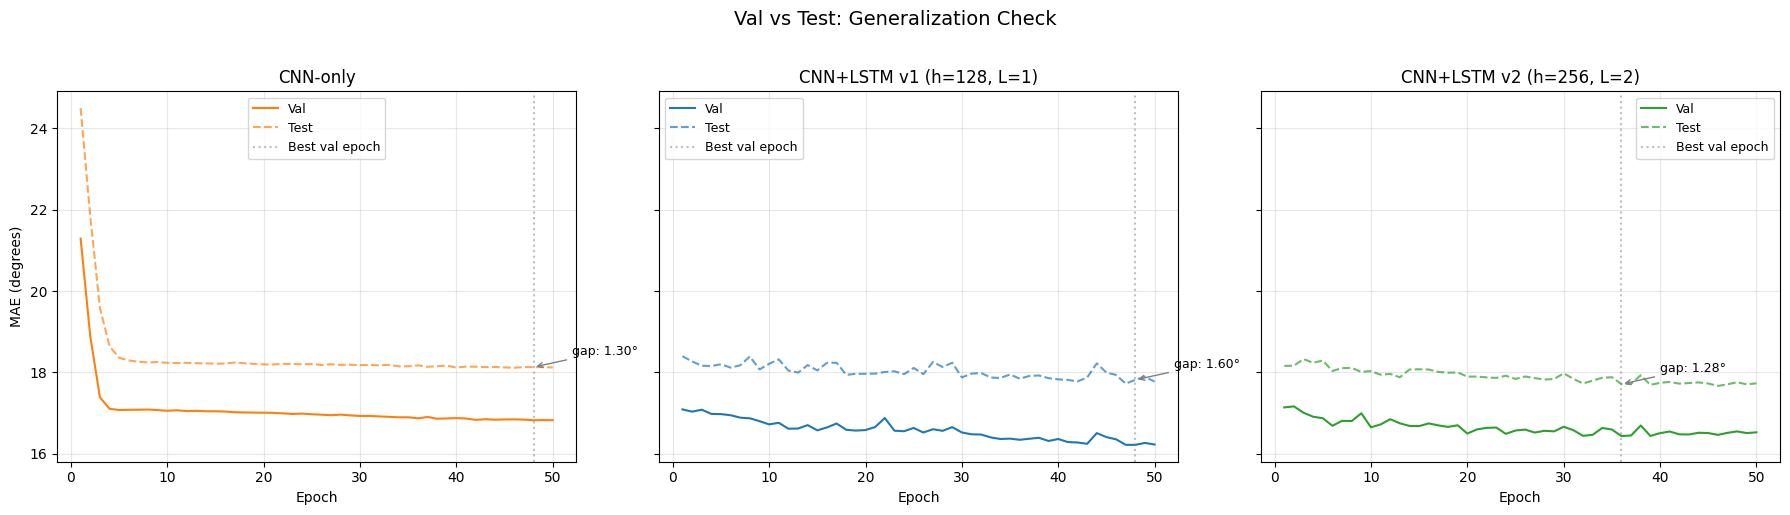

In [15]:
# Only include models that have test_loss
has_test = {k: v for k, v in histories.items() if 'test_loss' in v}
n = len(has_test)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True, squeeze=False)
axes = axes[0]

for ax, name in zip(axes, has_test):
    label, color = LABELS[name]
    epochs = range(1, len(has_test[name]['val_loss']) + 1)
    val_deg = np.rad2deg(has_test[name]['val_loss'])
    test_deg = np.rad2deg(has_test[name]['test_loss'])

    ax.plot(epochs, val_deg, color=color, label='Val')
    ax.plot(epochs, test_deg, color=color, linestyle='--', alpha=0.7, label='Test')

    # Mark best val epoch
    best_idx = int(np.argmin(has_test[name]['val_loss']))
    ax.axvline(best_idx + 1, color='gray', linestyle=':', alpha=0.5, label='Best val epoch')

    # Annotate the gap at best epoch
    gap = test_deg[best_idx] - val_deg[best_idx]
    ax.annotate(f'gap: {gap:.2f}\u00b0',
                xy=(best_idx + 1, test_deg[best_idx]),
                xytext=(best_idx + 5, test_deg[best_idx] + 0.3),
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9)

    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('MAE (degrees)')
fig.suptitle('Val vs Test: Generalization Check', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4. Test loss comparison (all models)

Which model has the best held-out performance over training

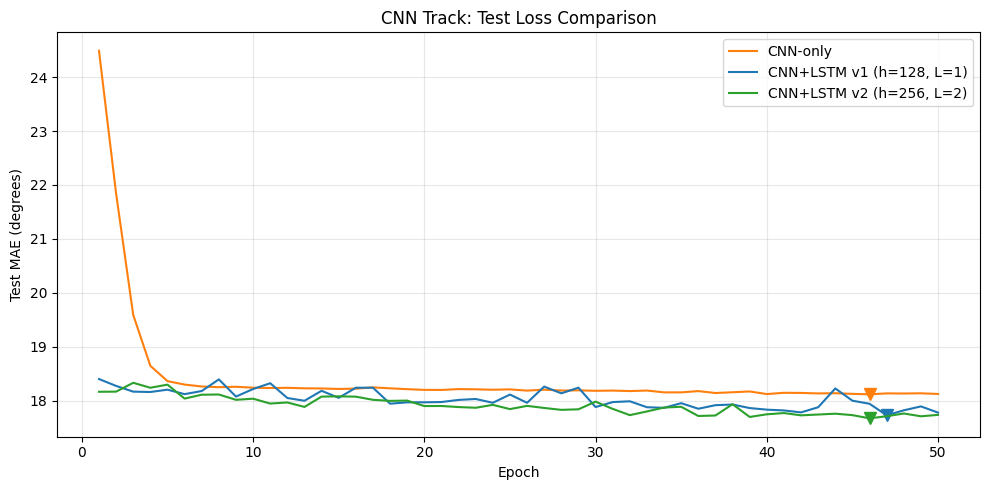

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in histories:
    if 'test_loss' not in histories[name]:
        continue
    label, color = LABELS[name]
    epochs = range(1, len(histories[name]['test_loss']) + 1)
    test_deg = np.rad2deg(histories[name]['test_loss'])
    ax.plot(epochs, test_deg, color=color, label=label)

    # Mark best test epoch
    best_idx = int(np.argmin(histories[name]['test_loss']))
    ax.plot(best_idx + 1, test_deg[best_idx], 'v', color=color, markersize=8)

ax.set_xlabel('Epoch')
ax.set_ylabel('Test MAE (degrees)')
ax.set_title('CNN Track: Test Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. LR schedule

All models use ReduceLROnPlateau (factor=0.5, patience=3)

Each step down = val loss stopped improving for 3 epochs

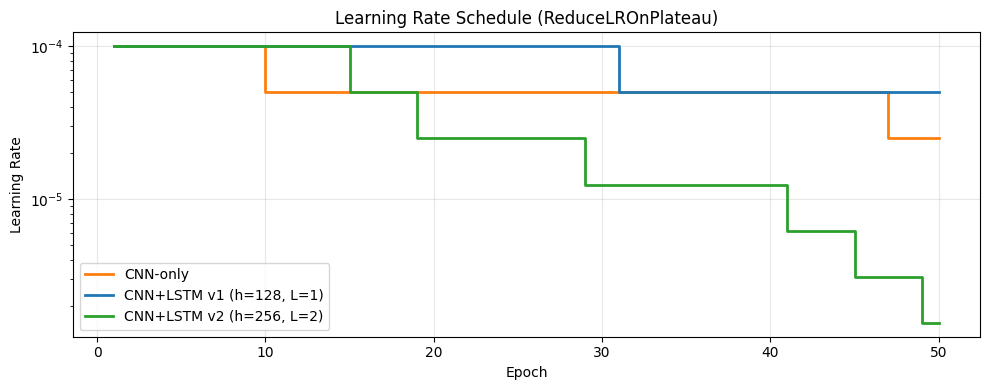

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

for name in histories:
    if 'lr' not in histories[name]:
        continue
    label, color = LABELS[name]
    epochs = range(1, len(histories[name]['lr']) + 1)
    ax.plot(epochs, histories[name]['lr'],
            color=color, label=label, linewidth=2, drawstyle='steps-post')

ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_yscale('log')
ax.set_title('Learning Rate Schedule (ReduceLROnPlateau)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Summary table

In [18]:
import pandas as pd

PARAMS = {
    'cnn_only': ('CNN-only', '28K', '\u2014', '\u2014'),
    'cnn_lstm': ('CNN+LSTM v1', '98K', 128, 1),
    'cnn_lstm_v2': ('CNN+LSTM v2', '849K', 256, 2),
}

rows = []
for name in histories:
    label, params, hidden, layers = PARAMS[name]
    h = histories[name]
    best_epoch = int(np.argmin(h['val_loss'])) + 1
    train_gap = np.rad2deg(h['val_loss'][best_epoch - 1]) - np.rad2deg(h['train_loss'][best_epoch - 1])

    row = {
        'Model': label,
        'Params': params,
        'Best Epoch': best_epoch,
        'Train MAE': f"{np.rad2deg(h['train_loss'][best_epoch - 1]):.2f}\u00b0",
        'Val MAE': f"{np.rad2deg(h['val_loss'][best_epoch - 1]):.2f}\u00b0",
        'Train-Val Gap': f"{train_gap:.2f}\u00b0",
    }
    if 'test_loss' in h:
        row['Test MAE'] = f"{np.rad2deg(h['test_loss'][best_epoch - 1]):.2f}\u00b0"
        val_test_gap = np.rad2deg(h['test_loss'][best_epoch - 1]) - np.rad2deg(h['val_loss'][best_epoch - 1])
        row['Val-Test Gap'] = f"{val_test_gap:.2f}\u00b0"
    else:
        row['Test MAE'] = '\u2014'
        row['Val-Test Gap'] = '\u2014'
    rows.append(row)

display(pd.DataFrame(rows))

,Model,Params,Best Epoch,Train MAE,Val MAE,Train-Val Gap,Test MAE,Val-Test Gap
0,CNN-only,28K,48,16.64°,16.83°,0.18°,18.13°,1.30°
1,CNN+LSTM v1,98K,48,15.99°,16.22°,0.23°,17.82°,1.60°
2,CNN+LSTM v2,849K,36,15.99°,16.44°,0.44°,17.71°,1.28°
